# The Art and Science of Pastry Prediction: A Data-Driven Approach

This notebook follows the flow of the final pastry forecasting report while using modular Python files from the `src/` folder. The notebook now supports the **actual competition workflow**:

1. statement of purpose and scope  
2. data loading and initial inspection  
3. data cleaning and preprocessing  
4. baseline exploratory data analysis  
5. feature engineering  
6. feature validation  
7. **time-based model development and comparison**  
8. **competition submission generation**  
9. business impact, conclusion, and recommendations


## 1. Statement of Purpose

Accurate demand forecasting is crucial in the food industry, especially for bakeries producing perishable goods. Poor forecasts can lead to overproduction, food waste, lost margin, and customer dissatisfaction.

This notebook builds a machine learning-based pastry sales forecasting workflow designed to support production planning, reduce waste, and improve store-level decision making.


## 2. Scope of the Project

The project forecasts daily pastry sales at the **store-day grain** using:
- historical sales
- holiday indicators
- weather variables
- time-based and lag-based engineered features

The target variable is `sales`, and the final workflow compares multiple regression models using **time-based validation** before generating predictions for the competition `test.csv`.


## 3. Environment Setup and Imports

In [1]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.analysis import (
    load_raw_data,
    run_time_based_analysis,
    build_submission_from_paths,
)
from src.data_cleaning import clean_pastry_data
from src.feature_engineering import build_features
from src.visualization import (
    generate_eda_figures,
    generate_feature_validation_figures,
    generate_time_based_model_figures,
    plot_sales_over_time,
    plot_sales_distribution,
    plot_sales_by_weekday,
    plot_sales_by_month,
    plot_correlation_heatmap,
    plot_lag_relationship,
    plot_rolling_feature_comparison,
    plot_model_comparison,
    plot_model_r2_comparison,
    plot_predictions_vs_actual,
    plot_residuals,
    plot_submission_distribution,
)

TRAIN_PATH = PROJECT_ROOT / "data" / "raw" / "train.csv"
TEST_PATH = PROJECT_ROOT / "data" / "raw" / "test.csv"
SUBMISSION_TEMPLATE_PATH = PROJECT_ROOT / "data" / "raw" / "sample_submission.csv"

TRAIN_PATH, TEST_PATH, SUBMISSION_TEMPLATE_PATH

(WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/data/raw/train.csv'),
 WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/data/raw/test.csv'),
 WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/data/raw/sample_submission.csv'))

### Figure Naming Convention

All plots now:
- display inline in the notebook
- save automatically to `figures/`
- use report-aligned file names such as:
  - `fig_6_1_sales_over_time.png`
  - `fig_8_1_sales_lag_1_relationship.png`
  - `fig_9_1_time_based_model_comparison_test_mse.png`


## Notebook Execution Setup

Run the next cell if you need to install dependencies inside your notebook environment.  
For local environments, this uses the repository's root `requirements.txt`.


In [2]:
# Optional: install project dependencies
# Uncomment the next line if you are running this notebook in a fresh environment.
# %pip install -r ../requirements.txt

## File and Path Validation

This cell checks that the expected competition files exist before the pipeline is executed.


In [3]:
from pathlib import Path

required_paths = {
    "train": TRAIN_PATH,
    "test": TEST_PATH,
    "sample_submission": SUBMISSION_TEMPLATE_PATH,
}

for label, path in required_paths.items():
    print(f"{label}: {path} -> {'FOUND' if Path(path).exists() else 'MISSING'}")

train: D:\Users\RSM\Downloads\Data Analytics\Pastry\pastry-sales-forecasting-\data\raw\train.csv -> FOUND
test: D:\Users\RSM\Downloads\Data Analytics\Pastry\pastry-sales-forecasting-\data\raw\test.csv -> FOUND
sample_submission: D:\Users\RSM\Downloads\Data Analytics\Pastry\pastry-sales-forecasting-\data\raw\sample_submission.csv -> FOUND


## 4. Data Loading and Initial Inspection

The raw competition files include:
- `train.csv` with the target `sales`
- `test.csv` without `sales`
- `sample_submission.csv` with the required output structure

This section verifies the structure before any transformations are applied.


In [4]:
df_raw = load_raw_data(TRAIN_PATH)
df_test_raw = load_raw_data(TEST_PATH)
sample_submission = load_raw_data(SUBMISSION_TEMPLATE_PATH)

print("Train shape:", df_raw.shape)
print("Test shape:", df_test_raw.shape)
print("Sample submission shape:", sample_submission.shape)

display(df_raw.head())
display(df_test_raw.head())
display(sample_submission.head())

Train shape: (5142, 13)
Test shape: (1575, 13)
Sample submission shape: (1575, 4)


,date,store,is_state_holiday,is_school_holiday,is_special_day,temperature_max,temperature_min,temperature_mean,sunshine_sum,precipitation_sum,sales,unsold,ordered
0,2021-08-02,store_5,normal_day,school_holiday,normal_day,21.8,16.3,19.590909,203,0.0,1.432748,NaN,NaN
1,2021-08-02,store_8,normal_day,school_holiday,normal_day,21.8,16.3,19.590909,203,0.0,1.253193,NaN,NaN
2,2021-08-02,store_7,normal_day,school_holiday,normal_day,21.8,16.3,19.590909,203,0.0,0.985026,NaN,NaN
3,2021-08-02,store_4,normal_day,school_holiday,normal_day,21.8,16.3,19.590909,203,0.0,0.889419,NaN,NaN
4,2021-08-02,store_1,normal_day,school_holiday,normal_day,21.8,16.3,19.590909,203,0.0,0.572282,NaN,NaN


,row_id,date,store,is_state_holiday,is_school_holiday,is_special_day,temperature_max,temperature_min,temperature_mean,sunshine_sum,precipitation_sum,unsold,ordered
0,0,12/1/2023,store_3,normal_day,normal_day,normal_day,-0.8,-2.7,-1.709091,273,0.8,0,0
1,1,12/1/2023,store_5,normal_day,normal_day,normal_day,-2.7,-6.4,-4.554545,8,0.0,0,0
2,2,12/1/2023,store_1,normal_day,normal_day,normal_day,-2.7,-6.4,-4.554545,8,0.0,0,0
3,3,12/1/2023,store_4,normal_day,normal_day,normal_day,-2.7,-6.4,-4.554545,8,0.0,0,0
4,4,12/1/2023,store_7,normal_day,normal_day,normal_day,-2.7,-6.4,-4.554545,8,0.0,0,0


,row_id,sales,unsold,ordered
0,5142,-0.316820,0.553015,1.601786
1,5143,-0.105828,1.446403,0.121786
2,5144,1.757537,-2.538510,1.138624
3,5145,-0.674778,-0.015202,0.124183
4,5146,0.320501,0.676685,1.414249


In [5]:
display(df_raw.info())
display(df_raw.describe(include="all").transpose().head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5142 entries, 0 to 5141
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               5142 non-null   object 
 1   store              5142 non-null   object 
 2   is_state_holiday   5142 non-null   object 
 3   is_school_holiday  5142 non-null   object 
 4   is_special_day     5142 non-null   object 
 5   temperature_max    5142 non-null   float64
 6   temperature_min    5142 non-null   float64
 7   temperature_mean   5142 non-null   float64
 8   sunshine_sum       5142 non-null   int64  
 9   precipitation_sum  5142 non-null   float64
 10  sales              5142 non-null   float64
 11  unsold             3226 non-null   float64
 12  ordered            3226 non-null   float64
dtypes: float64(7), int64(1), object(5)
memory usage: 522.4+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,5142,847,2023-11-15,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store,5142,9,store_5,847,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_state_holiday,5142,4,normal_day,5025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_school_holiday,5142,2,normal_day,3957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_special_day,5142,3,normal_day,4947,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature_max,5142.0,NaN,NaN,NaN,15.60142,8.317952,-4.4,8.9,16.0,21.9,37.7
temperature_min,5142.0,NaN,NaN,NaN,10.825729,6.946531,-8.1,5.8,10.95,16.2,30.2
temperature_mean,5142.0,NaN,NaN,NaN,13.641699,7.825537,-5.654545,7.581818,13.827273,19.754545,35.172727
sunshine_sum,5142.0,NaN,NaN,NaN,179.550758,162.651716,0.0,11.0,148.0,308.0,551.0
precipitation_sum,5142.0,NaN,NaN,NaN,0.916725,2.596219,0.0,0.0,0.0,0.4,32.2


### Interpretation

The uploaded competition dataset has the expected Kaggle-style structure:
- train rows contain the target `sales`
- test rows contain `row_id` but no `sales`
- final evaluation must therefore rely on an internal validation split rather than the competition test set


## 5. Data Cleaning and Preprocessing

The cleaning step standardizes column names, converts the date field, encodes the store identifier, imputes selected missing values, and sorts the dataset in time order.


In [6]:
df_clean = clean_pastry_data(df_raw)
print("Cleaned shape:", df_clean.shape)
display(df_clean.head())
display(df_clean.isna().sum().sort_values(ascending=False).head(15))

Cleaned shape: (5142, 14)


,date,store_id,is_state_holiday,is_school_holiday,is_special_day,temperature_max,temperature_min,temperature_mean,sunshine_sum,precipitation_sum,sales,unsold,ordered,store_num
0,2023-03-02,store_0,normal_day,normal_day,normal_day,2.8,-0.1,1.809091,0,0.0,-1.204614,-0.078293,-1.049955,7
1,2023-03-03,store_0,normal_day,normal_day,normal_day,5.8,2.4,4.800000,1,0.0,-1.043714,-0.027102,-0.870327,7
2,2023-03-04,store_0,normal_day,normal_day,normal_day,6.6,2.6,4.654545,18,0.0,-0.733573,0.740761,-0.336233,7
3,2023-03-05,store_0,normal_day,normal_day,normal_day,5.0,0.2,2.845455,92,2.3,-1.216273,2.165574,-0.432035,7
4,2023-03-06,store_0,normal_day,school_holiday,normal_day,4.6,2.0,3.309091,205,0.0,-1.442466,1.013779,-0.987684,7


date                 0
store_id             0
is_state_holiday     0
is_school_holiday    0
is_special_day       0
temperature_max      0
temperature_min      0
temperature_mean     0
sunshine_sum         0
precipitation_sum    0
sales                0
unsold               0
ordered              0
store_num            0
dtype: int64

### Cleaning Notes

This notebook uses a light-touch cleaning philosophy:
- preserve observations whenever possible
- impute only selected operational columns
- leave competition-specific lag construction to the feature engineering stage


## 6. Baseline Exploratory Data Analysis (EDA)

This section is strictly descriptive. It is used to understand:
- overall sales movement over time
- weekly demand patterns
- seasonal monthly variation
- sales distribution
- baseline numeric correlations


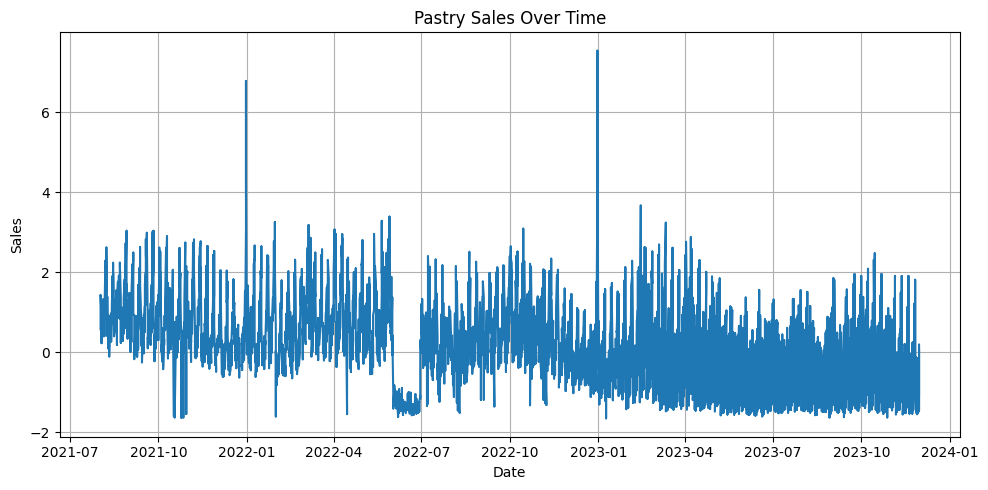

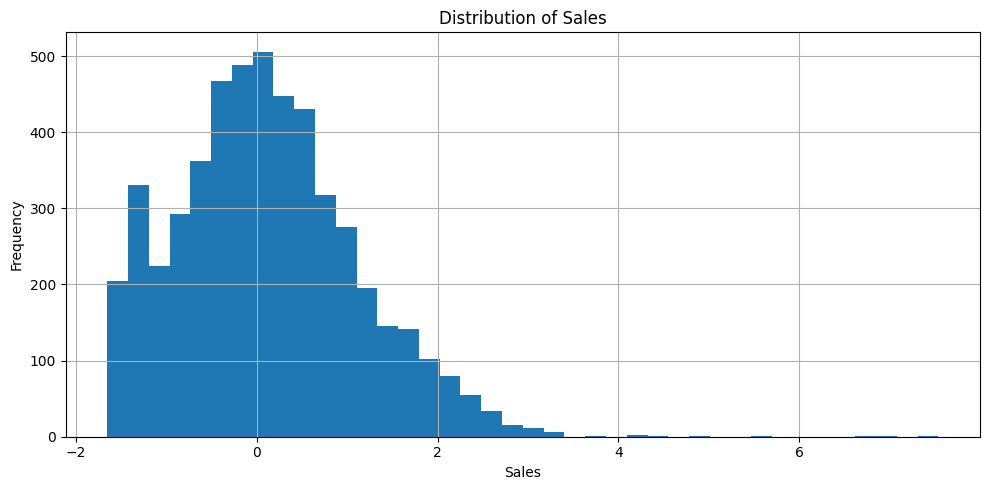

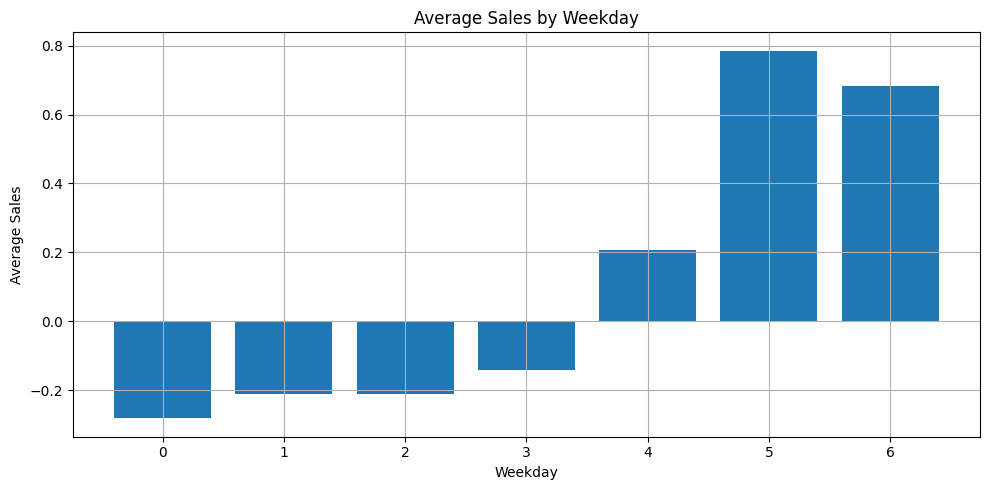

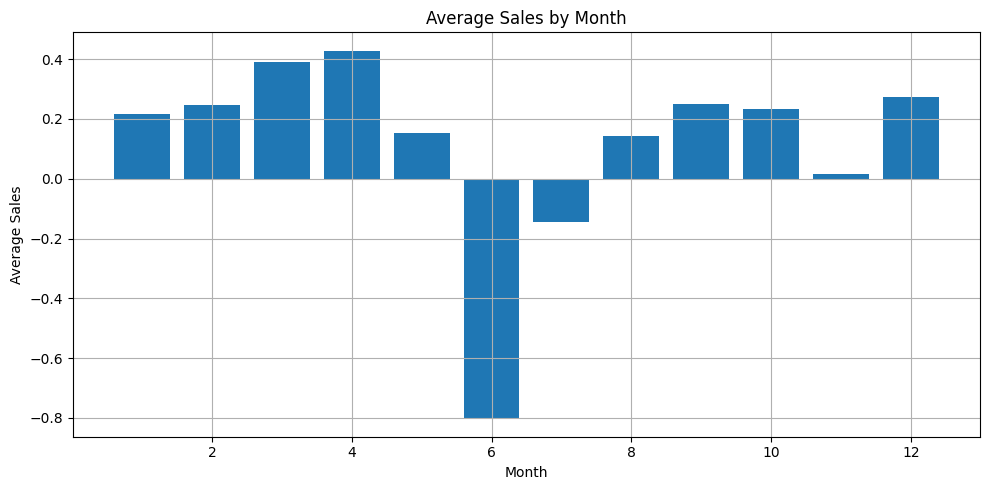

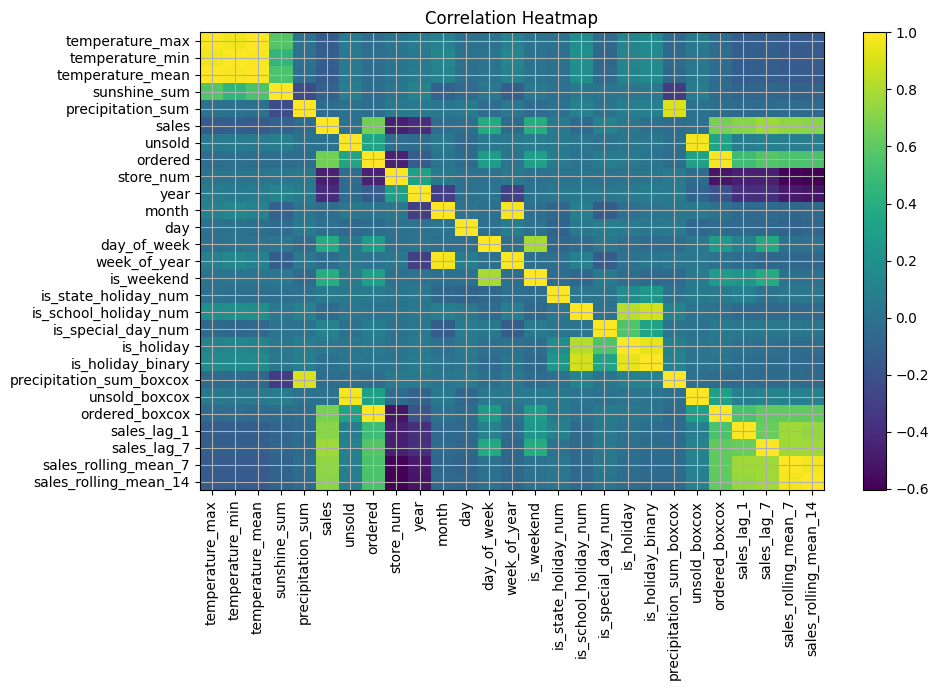

[WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_6_1_sales_over_time.png'),
 WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_6_2_sales_distribution.png'),
 WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_6_3_sales_by_weekday.png'),
 WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_6_4_sales_by_month.png'),
 WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_6_5_correlation_heatmap.png')]

In [7]:
eda_ready_df = build_features(df_clean)
eda_paths = generate_eda_figures(eda_ready_df)
eda_paths

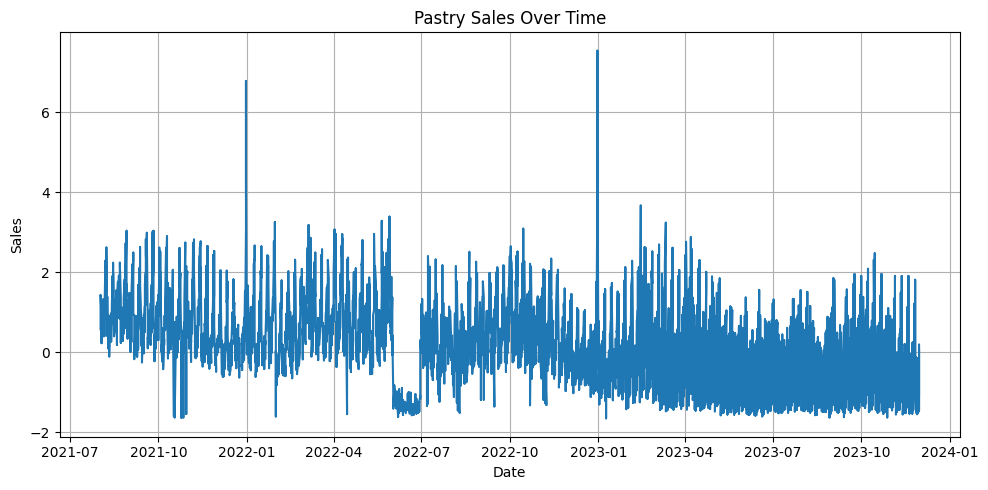

WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_6_1_sales_over_time.png')

In [8]:
plot_sales_over_time(eda_ready_df)

### 6.1 Interpretation - Sales Over Time

This visualization helps identify trend direction, seasonality, and potential regime shifts. If strong movement is visible across time, time-based and lag-based features become more justified.


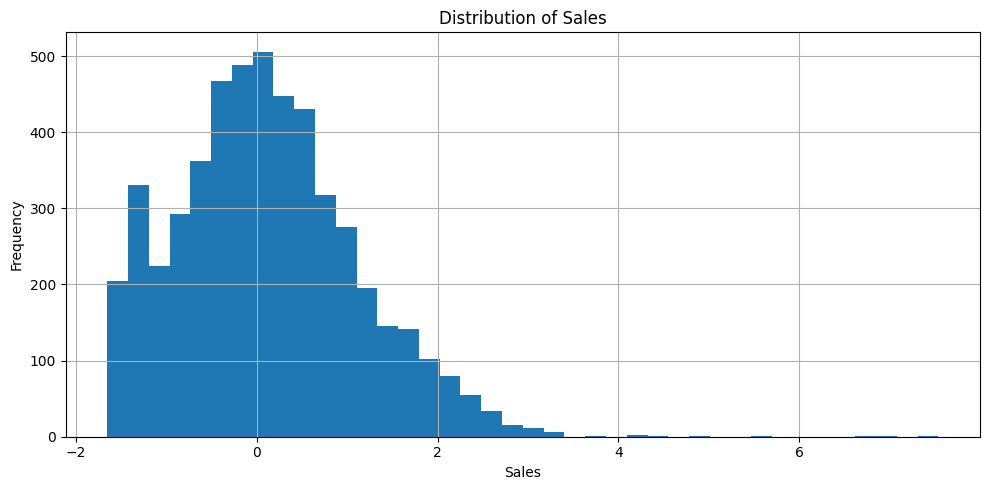

WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_6_2_sales_distribution.png')

In [9]:
plot_sales_distribution(eda_ready_df)

### 6.2 Interpretation - Distribution of Sales

This chart shows the shape of the target variable. Skewness, outliers, or clustering in the sales distribution can affect preprocessing choices and model fit.


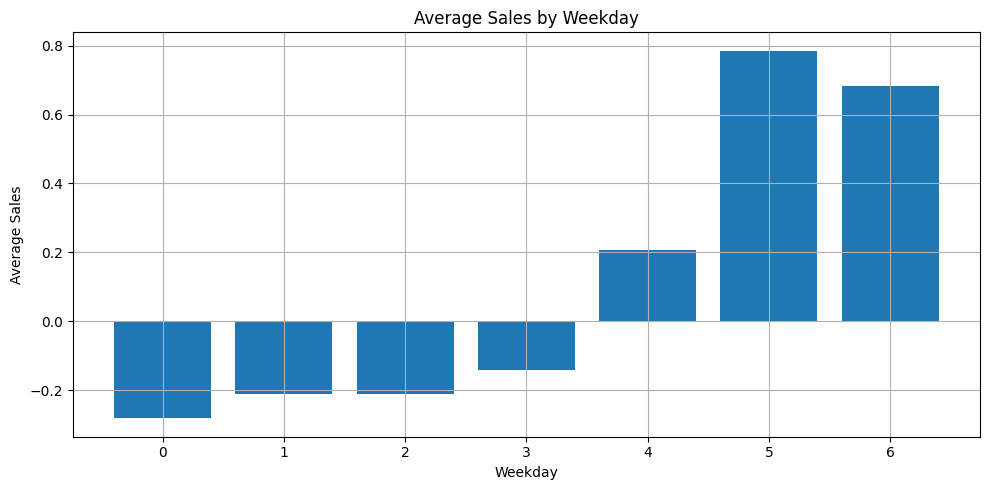

WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_6_3_sales_by_weekday.png')

In [10]:
plot_sales_by_weekday(eda_ready_df)

### 6.3 Interpretation - Average Sales by Weekday

If weekday averages differ materially, then day-of-week effects are likely useful predictors in the forecasting model.


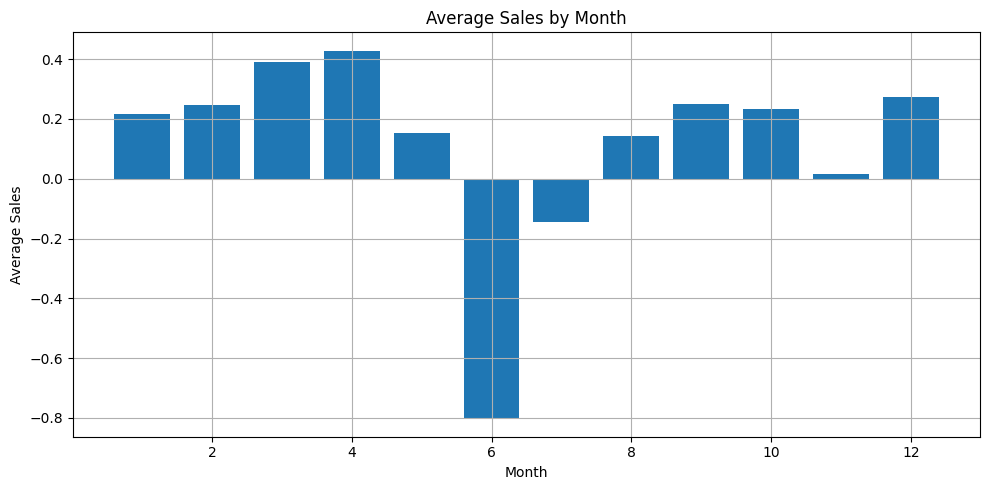

WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_6_4_sales_by_month.png')

In [11]:
plot_sales_by_month(eda_ready_df)

### 6.4 Interpretation - Average Sales by Month

Monthly changes help reveal broader seasonality and support the use of calendar variables such as `month`.


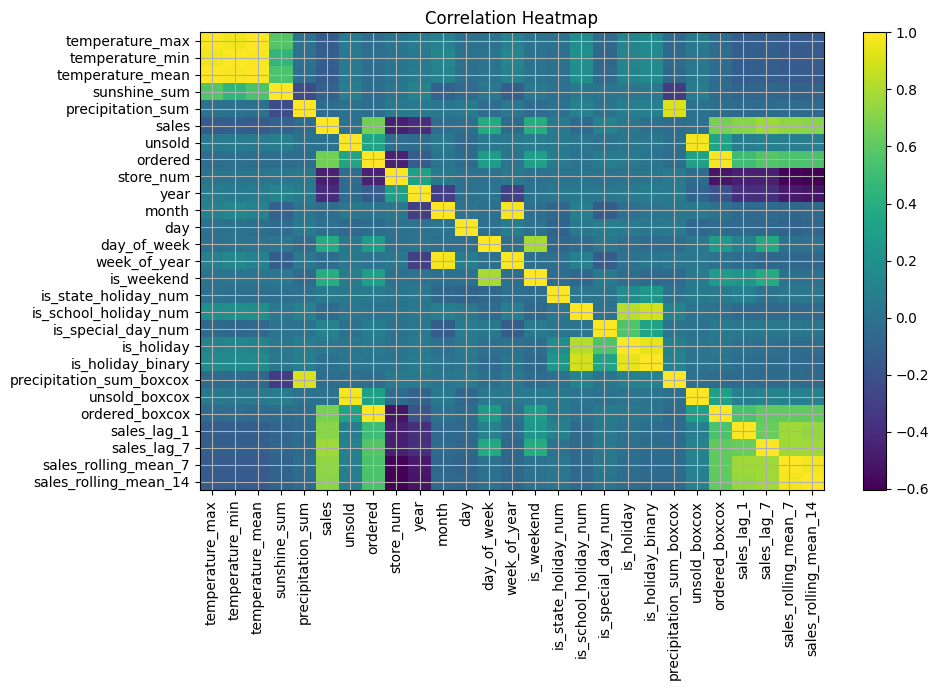

WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_6_5_correlation_heatmap.png')

In [12]:
plot_correlation_heatmap(eda_ready_df)

### 6.5 Interpretation - Correlation Heatmap

This plot provides a quick structural view of numeric relationships among variables. It does not replace model validation, but it helps identify promising predictors and possible redundancy.


## 7. Feature Engineering

This section transforms the cleaned dataset into a modeling-ready structure by creating:
- date features
- encoded holiday variables
- transformed operational variables
- lag features
- rolling mean features


In [13]:
df_fe = build_features(df_clean)
print("Feature-engineered shape:", df_fe.shape)
display(df_fe.head())
display(df_fe.columns.tolist())

Feature-engineered shape: (5142, 32)


,date,store_id,is_state_holiday,is_school_holiday,is_special_day,temperature_max,temperature_min,temperature_mean,sunshine_sum,precipitation_sum,...,is_special_day_num,is_holiday,is_holiday_binary,precipitation_sum_boxcox,unsold_boxcox,ordered_boxcox,sales_lag_1,sales_lag_7,sales_rolling_mean_7,sales_rolling_mean_14
0,2023-03-02,store_0,normal_day,normal_day,normal_day,2.8,-0.1,1.809091,0,0.0,...,0,0,0,0.693148,1.166744,0.980513,NaN,NaN,NaN,NaN
1,2023-03-03,store_0,normal_day,normal_day,normal_day,5.8,2.4,4.800000,1,0.0,...,0,0,0,0.693148,1.182558,1.045721,-1.204614,NaN,-1.204614,-1.204614
2,2023-03-04,store_0,normal_day,normal_day,normal_day,6.6,2.6,4.654545,18,0.0,...,0,0,0,0.693148,1.393908,1.217741,-1.043714,NaN,-1.124164,-1.124164
3,2023-03-05,store_0,normal_day,normal_day,normal_day,5.0,0.2,2.845455,92,2.3,...,0,0,0,1.458615,1.696603,1.188984,-0.733573,NaN,-0.993967,-0.993967
4,2023-03-06,store_0,normal_day,school_holiday,normal_day,4.6,2.0,3.309091,205,0.0,...,0,2,1,0.693148,1.459450,1.003603,-1.216273,NaN,-1.049543,-1.049543


['date',
 'store_id',
 'is_state_holiday',
 'is_school_holiday',
 'is_special_day',
 'temperature_max',
 'temperature_min',
 'temperature_mean',
 'sunshine_sum',
 'precipitation_sum',
 'sales',
 'unsold',
 'ordered',
 'store_num',
 'year',
 'month',
 'day',
 'day_of_week',
 'week_of_year',
 'is_weekend',
 'is_state_holiday_num',
 'is_school_holiday_num',
 'is_special_day_num',
 'is_holiday',
 'is_holiday_binary',
 'precipitation_sum_boxcox',
 'unsold_boxcox',
 'ordered_boxcox',
 'sales_lag_1',
 'sales_lag_7',
 'sales_rolling_mean_7',
 'sales_rolling_mean_14']

## 8. Feature Validation

Before modeling, the engineered variables should be checked for logical consistency and usefulness. This section validates whether lag and rolling features behave as expected.


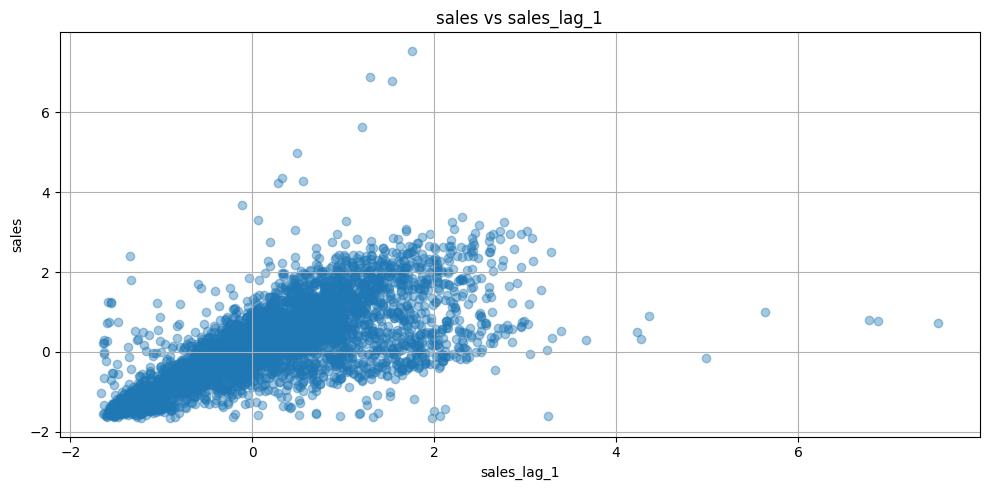

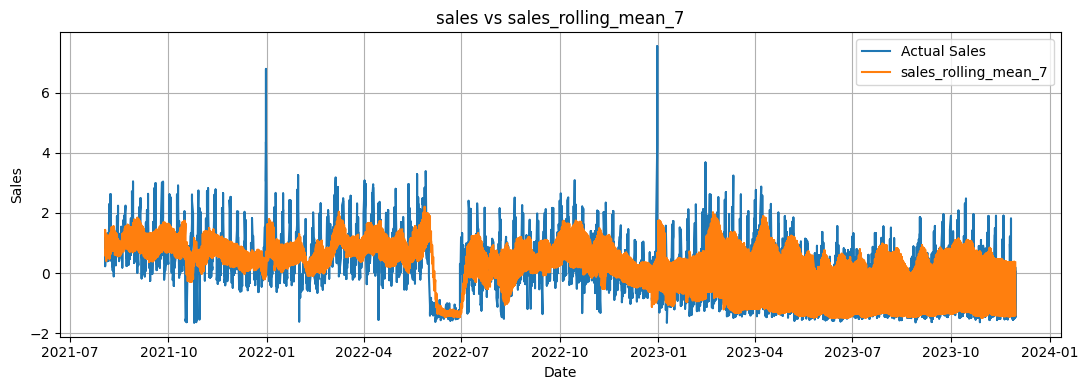

[WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_8_1_sales_lag_1_relationship.png'),
 WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_8_2_sales_rolling_mean_7_comparison.png')]

In [14]:
validation_paths = generate_feature_validation_figures(df_fe)
validation_paths

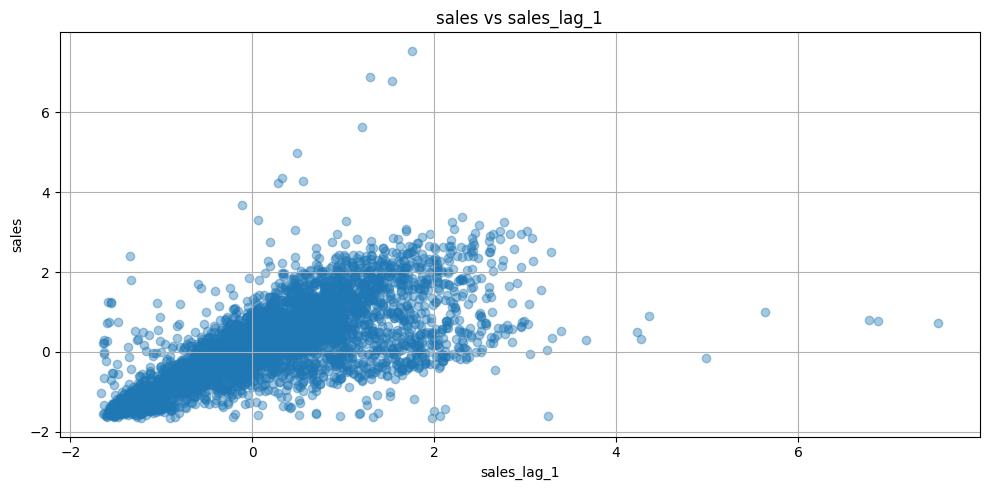

WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_8_1_sales_lag_1_relationship.png')

In [15]:
plot_lag_relationship(df_fe, lag_col="sales_lag_1")

### 8.1 Interpretation - Lag Feature Relationship

A visible positive relationship between `sales` and `sales_lag_1` suggests that recent sales contain short-term predictive signal.


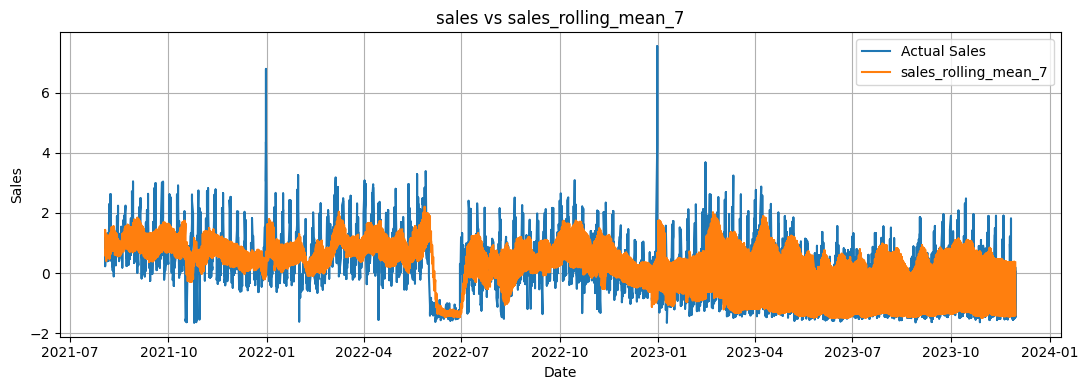

WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_8_2_sales_rolling_mean_7_comparison.png')

In [16]:
plot_rolling_feature_comparison(df_fe, rolling_col="sales_rolling_mean_7")

### 8.2 Interpretation - Rolling Mean Comparison

The rolling mean smooths short-term noise and often acts as a strong baseline demand signal in forecasting tasks.


## 9. Time-Based Model Development and Comparison

Because the competition test set contains future rows and no `sales`, evaluation should use a **time-based validation split** instead of a random split.

This section:
- builds the processed training dataset
- creates a chronological validation window
- compares candidate models using time-aware validation


In [17]:
df_model, time_results_df, time_predictions_df, trained_models, features, train_window_df, valid_window_df = run_time_based_analysis(TRAIN_PATH)

print("Features used:")
print(features)
display(time_results_df)

Features used:
['temperature_mean', 'sunshine_sum', 'precipitation_sum_boxcox', 'unsold_boxcox', 'ordered_boxcox', 'store_num', 'is_state_holiday_num', 'is_school_holiday_num', 'is_special_day_num', 'day_of_week', 'month', 'is_weekend', 'sales_lag_1', 'sales_lag_7', 'sales_rolling_mean_7', 'sales_rolling_mean_14']


,model,cv_mse,test_mse,test_r2,n_features
0,XGBoost,0.317267,0.025968,0.959253,16
1,Random Forest,0.340835,0.028360,0.955501,16
2,Decision Tree,0.531306,0.076076,0.880628,16
3,Linear Regression,0.543179,0.080622,0.873495,16


### 9.1 Interpretation - Time-Based Model Comparison

This table provides the main model-selection evidence for forecasting future periods. Lower validation MSE indicates stronger predictive accuracy on later unseen dates, which is more realistic for this competition than a random split.


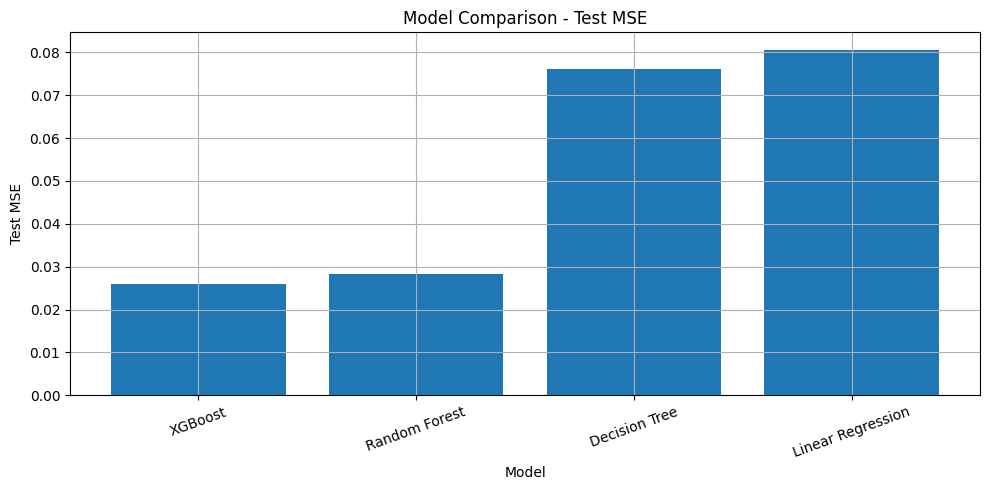

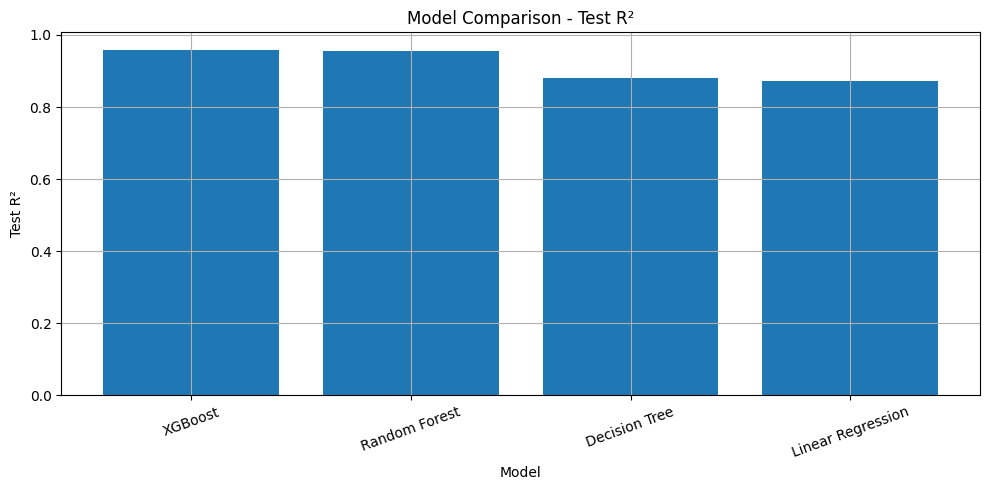

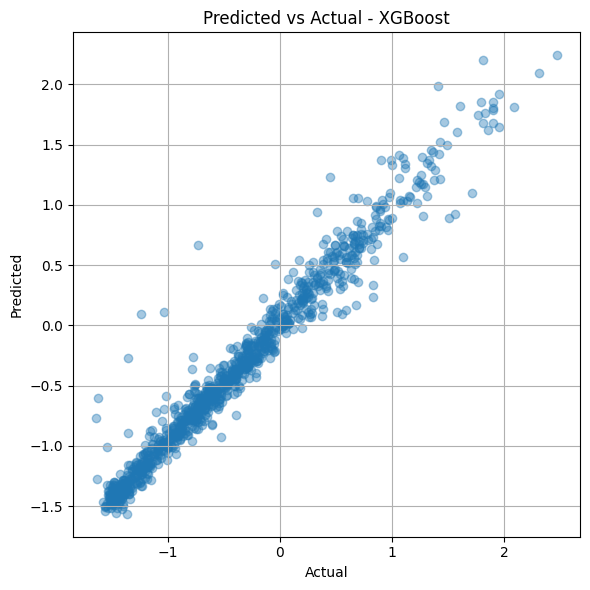

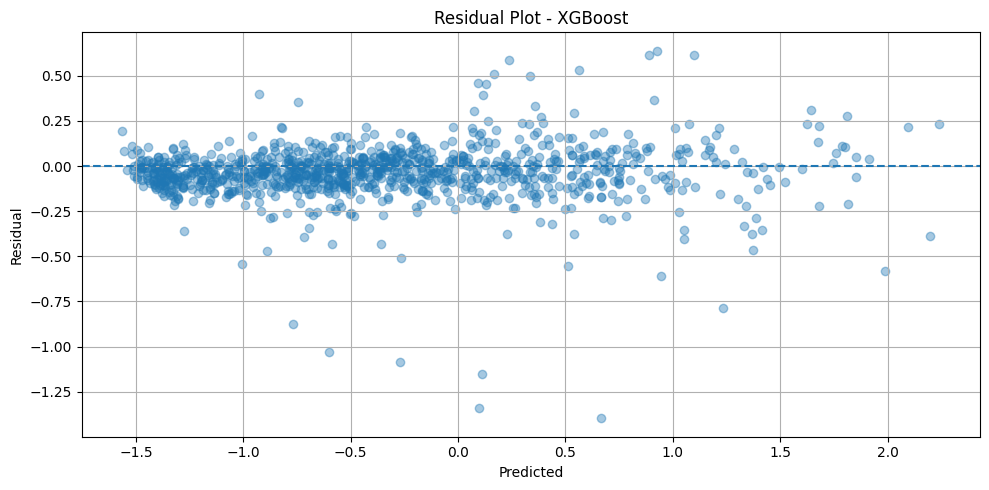

[WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_9_1_time_based_model_comparison_test_mse.png'),
 WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_9_2_time_based_model_comparison_test_r2.png'),
 WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_9_3_time_based_predicted_vs_actual.png'),
 WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_9_4_time_based_residual_plot.png')]

In [18]:
time_model_paths = generate_time_based_model_figures(time_results_df, time_predictions_df)
time_model_paths

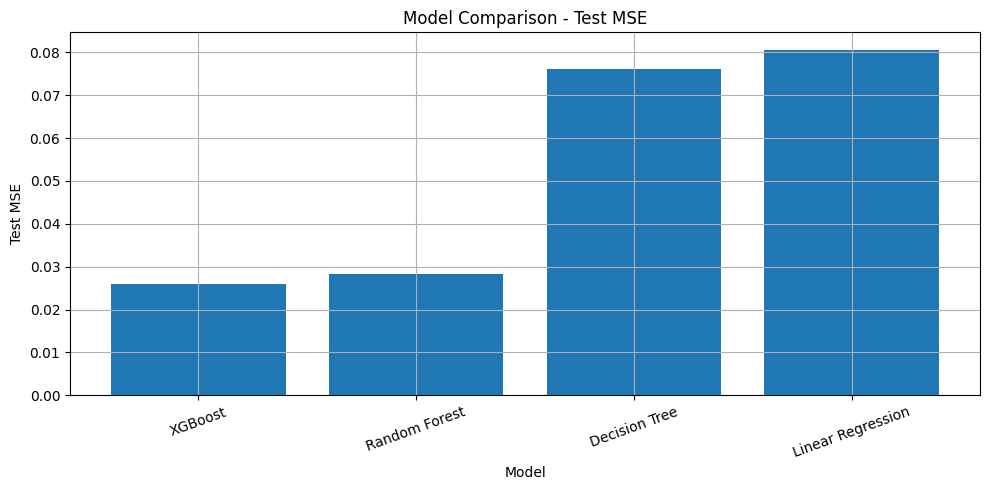

WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/time_based_model_comparison_test_mse.png')

In [19]:
plot_model_comparison(time_results_df, file_name="time_based_model_comparison_test_mse.png")

### 9.2 Interpretation - Validation MSE Comparison

This chart compares candidate models on the holdout future window. The lowest MSE indicates the most accurate forecasting model for the validation period.


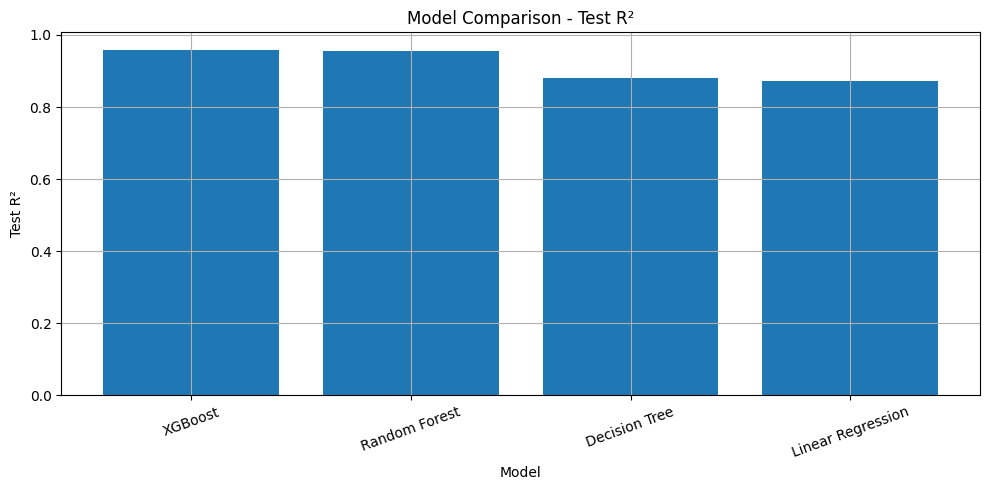

WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/time_based_model_comparison_test_r2.png')

In [20]:
plot_model_r2_comparison(time_results_df, file_name="time_based_model_comparison_test_r2.png")

### 9.3 Interpretation - Validation R² Comparison

This chart complements MSE by showing how much variance each model explains on the later holdout period.


In [21]:
best_model_name = time_results_df.iloc[0]["model"]
best_model_name

'XGBoost'

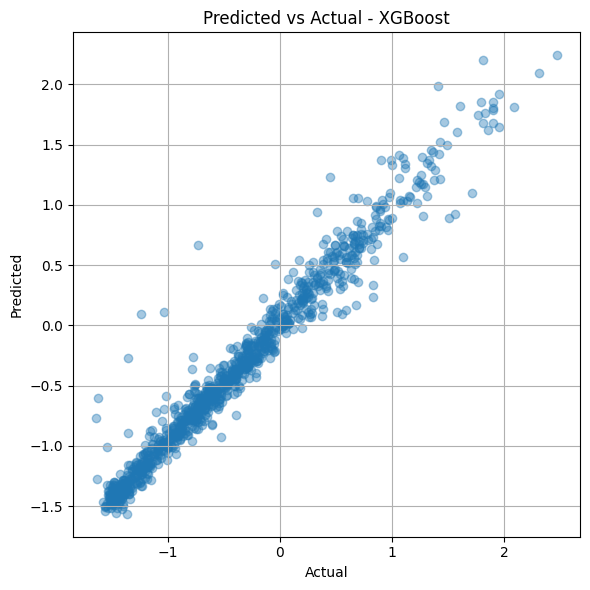

WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/time_based_predicted_vs_actual.png')

In [22]:
plot_predictions_vs_actual(
    time_predictions_df,
    model_name=best_model_name,
    file_name="time_based_predicted_vs_actual.png",
)

### 9.4 Interpretation - Predicted vs Actual (Time-Based)

A tighter alignment between predicted and actual values indicates stronger future-period forecasting performance.


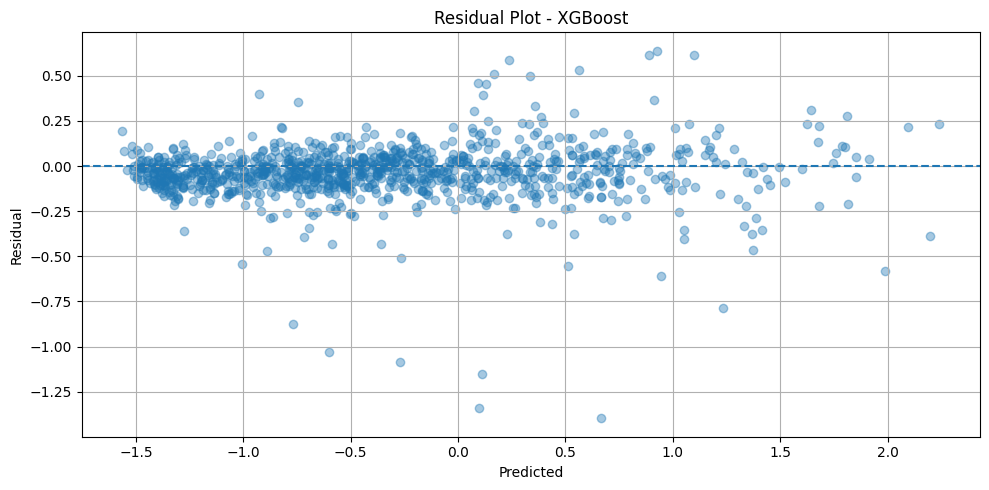

WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/time_based_residual_plot.png')

In [23]:
plot_residuals(
    time_predictions_df,
    model_name=best_model_name,
    file_name="time_based_residual_plot.png",
)

### 9.5 Interpretation - Residual Analysis (Time-Based)

Residual analysis helps determine whether the selected forecasting model shows systematic bias on future dates.


## 10. Competition Submission Generation

After identifying the strongest model using time-based validation, the next step is to:
1. retrain that model on the full training dataset
2. generate predictions for `test.csv`
3. export a competition-ready submission file


In [24]:
submission_df, best_submission_model, submission_features, time_based_results_df = build_submission_from_paths(
    TRAIN_PATH,
    TEST_PATH,
    submission_file_name="submission.csv",
)

print("Best model used for submission:", best_submission_model)
print("Submission features:", submission_features)
display(submission_df.head())

Best model used for submission: XGBoost
Submission features: ['temperature_mean', 'sunshine_sum', 'precipitation_sum_boxcox', 'unsold_boxcox', 'ordered_boxcox', 'store_num', 'is_state_holiday_num', 'is_school_holiday_num', 'is_special_day_num', 'day_of_week', 'month', 'is_weekend', 'sales_lag_1', 'sales_lag_7', 'sales_rolling_mean_7', 'sales_rolling_mean_14']


,row_id,sales
5142,8.0,-1.136556
5323,2.0,-0.612763
5505,7.0,-0.857117
5626,0.0,-0.849644
5808,3.0,-0.283901


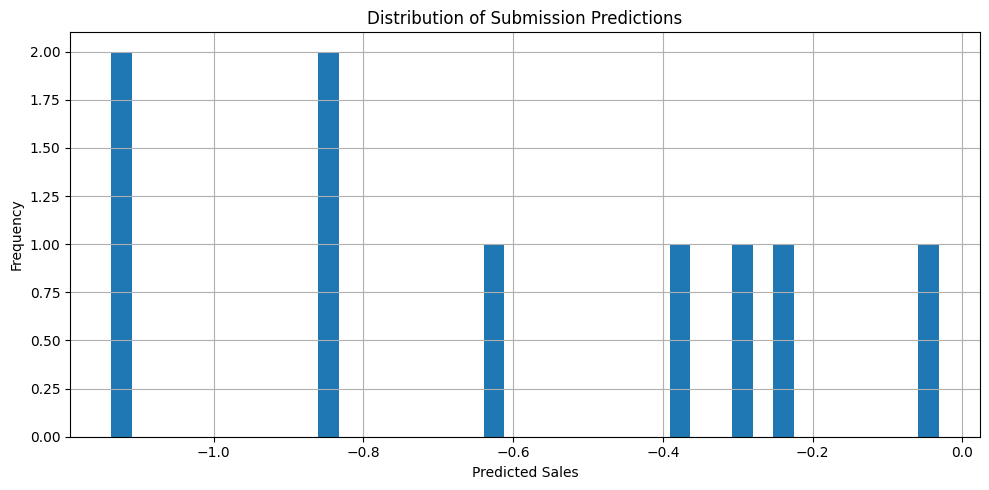

WindowsPath('D:/Users/RSM/Downloads/Data Analytics/Pastry/pastry-sales-forecasting-/figures/fig_10_1_submission_prediction_distribution.png')

In [25]:
plot_submission_distribution(submission_df)

### 10.1 Interpretation - Submission Prediction Distribution

This plot gives a sanity check on generated test-set forecasts. Extremely unusual distributions would signal a potential pipeline issue.


In [26]:
submission_template = load_raw_data(SUBMISSION_TEMPLATE_PATH)
print("Template columns:", submission_template.columns.tolist())
print("Generated submission columns:", submission_df.columns.tolist())

Template columns: ['row_id', 'sales', 'unsold', 'ordered']
Generated submission columns: ['row_id', 'sales']


## 11. Results Summary

At this point, the notebook has produced:
- a cleaned and feature-engineered training dataset
- saved processed parquet outputs for train and test
- time-based model comparison CSV output
- prediction diagnostics CSV output
- a competition-ready `reports/submission.csv`
- saved figures for EDA, feature validation, and model results


## 12. Business Impact

The forecasting workflow supports several operational benefits:

1. better production planning  
2. reduced overproduction and waste  
3. improved inventory and staffing decisions  
4. better preparedness for holiday and seasonal demand variation  
5. stronger data-driven planning across stores


## 13. Conclusion

This notebook demonstrates a reproducible end-to-end pastry sales forecasting workflow aligned to the real competition file structure. By combining modular preprocessing, engineered time-based features, time-aware validation, and competition submission generation, the project provides both analytical rigor and practical forecasting value.


## 14. Recommendations

Recommended next steps:
1. compare store-specific versus pooled models  
2. add promotion or local-event variables if available  
3. test richer walk-forward validation schemes  
4. tune the best model more aggressively  
5. connect forecasts to operational planning dashboards


## 15. Execution Summary

The next cell summarizes the key generated outputs so you can quickly verify that the workflow completed successfully.


In [27]:
from pathlib import Path

output_checks = {
    "processed_train_parquet": PROJECT_ROOT / "data" / "processed" / "pastry_train_processed.parquet",
    "processed_test_parquet": PROJECT_ROOT / "data" / "processed" / "pastry_test_processed.parquet",
    "time_based_results_csv": PROJECT_ROOT / "reports" / "time_based_model_comparison.csv",
    "submission_csv": PROJECT_ROOT / "reports" / "submission.csv",
    "eda_figure": PROJECT_ROOT / "figures" / "fig_6_1_sales_over_time.png",
    "feature_validation_figure": PROJECT_ROOT / "figures" / "fig_8_1_sales_lag_1_relationship.png",
    "model_figure": PROJECT_ROOT / "figures" / "fig_9_1_time_based_model_comparison_test_mse.png",
    "submission_figure": PROJECT_ROOT / "figures" / "fig_10_1_submission_prediction_distribution.png",
}

for label, path in output_checks.items():
    print(f"{label}: {path} -> {'FOUND' if Path(path).exists() else 'MISSING'}")

processed_train_parquet: D:\Users\RSM\Downloads\Data Analytics\Pastry\pastry-sales-forecasting-\data\processed\pastry_train_processed.parquet -> FOUND
processed_test_parquet: D:\Users\RSM\Downloads\Data Analytics\Pastry\pastry-sales-forecasting-\data\processed\pastry_test_processed.parquet -> FOUND
time_based_results_csv: D:\Users\RSM\Downloads\Data Analytics\Pastry\pastry-sales-forecasting-\reports\time_based_model_comparison.csv -> FOUND
submission_csv: D:\Users\RSM\Downloads\Data Analytics\Pastry\pastry-sales-forecasting-\reports\submission.csv -> FOUND
eda_figure: D:\Users\RSM\Downloads\Data Analytics\Pastry\pastry-sales-forecasting-\figures\fig_6_1_sales_over_time.png -> FOUND
feature_validation_figure: D:\Users\RSM\Downloads\Data Analytics\Pastry\pastry-sales-forecasting-\figures\fig_8_1_sales_lag_1_relationship.png -> FOUND
model_figure: D:\Users\RSM\Downloads\Data Analytics\Pastry\pastry-sales-forecasting-\figures\fig_9_1_time_based_model_comparison_test_mse.png -> FOUND
submis